#Understanding Tacoma Vehicle Theft Data

First, import the following libraries. 

In [111]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from matplotlib.patches import ConnectionPatch


Tacoma was downloaded data from Tacoma government website. It has crime data from 2018 through the present. Link here: https://data.tacoma.gov/. We're mainly going to focus on vehicle theft as Tacoma, WA was ranked as the #1 small city in the country for vehicle theft. 

In [112]:
#read csv into dataframe
crime_df = pd.read_csv("datasets\TPD_RMS_Crime.csv")

<>:2: SyntaxWarning: "\T" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\T"? A raw string is also an option.
<>:2: SyntaxWarning: "\T" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\T"? A raw string is also an option.
C:\Users\Tim Kim\AppData\Local\Temp\ipykernel_25296\2072681016.py:2: SyntaxWarning: "\T" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\T"? A raw string is also an option.
  crime_df = pd.read_csv("datasets\TPD_RMS_Crime.csv")
C:\Users\Tim Kim\AppData\Local\Temp\ipykernel_25296\2072681016.py:2: DtypeWarning: Columns (0: CaseNo, 1: OffenseCode) have mixed types. Specify dtype option on import or set low_memory=False.
  crime_df = pd.read_csv("datasets\TPD_RMS_Crime.csv")


Quick look at the dataframe. 

In [113]:
display(crime_df)

,NBD_name,NCD_name,NCD_neighborhood,Description,council_district,CaseNo,Division,Latitude,Longitude,Offense_Category,...,DateOccurred,Approximate_Time,Crimes_Against,Premise_Type,Gang_Related,Hate_Bias,TPD_District,TPD_Reporting_Block,OBJECTID,GlobalID
0,NaN,New Tacoma,New Tacoma Neighborhood Council,Destruction/Damage/Vandalism,2.0,2317409024,North,47.259788,-122.453841,Destruction/Damage/Vandalism,...,6/23/2023 12:00:00 AM,0:00,Property,Parking Lot,No/Unknown,None (No Bias),TA21,168,1,f2f15b0c-8cd1-4d18-96f8-527651525647
1,NaN,South End,South End Neighborhood Council,Larceny Theft,4.0,2002509011,South,47.209788,-122.437841,Larceny/Theft Offenses,...,1/24/2020 12:00:00 AM,0:00,Property,Other Residence,No/Unknown,None (No Bias),TA43,445,2,752a2797-a5e6-4397-9b8e-4f874e6884d7
2,NaN,South End,South End Neighborhood Council,Larceny Theft,4.0,2607801565,South,47.220648,-122.446540,Larceny/Theft Offenses,...,3/18/2026 12:00:00 AM,18:00,Property,Street/Right of Way,No/Unknown,None (No Bias),TA43,423,3,933454d3-e66f-4182-915a-494580118532
3,Oakland/madrona,South Tacoma,South Tacoma Neighborhood Council,Robbery - Gun,3.0,1905802142,South,47.231788,-122.492841,Robbery,...,2/27/2019 12:00:00 AM,23:00,Property,Convenience Store (7-11),No/Unknown,None (No Bias),TA32,401,4,bd1ac09b-97c9-4f15-a974-fbe2b986154d
4,NaN,South Tacoma,South Tacoma Neighborhood Council,Burglary,5.0,1828001367,South,47.197788,-122.471841,Burglary/Breaking & Entering,...,10/7/2018 12:00:00 AM,12:00,Property,Garage (Residential),No/Unknown,None (No Bias),TA33,415,5,4f883eea-f183-4197-a5ff-51719ac3a55a
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
222083,NaN,West End,West End Neighborhood Council,Destruction/Damage/Vandalism,1.0,2307601012,North,47.267788,-122.531841,Destruction/Damage/Vandalism,...,3/17/2023 12:00:00 AM,10:00,Property,Single Family Residence,No/Unknown,None (No Bias),TA24,107,222084,70d68a19-f4d9-4f93-bb6f-91b39ab2c962
222084,NaN,Eastside,Eastside Neighborhood Council,Traffic Accident/Collision - Non Fatal - Non I...,4.0,2328602092,South,47.223788,-122.420841,Traffic Accident/Collision - Non Fatal - Non I...,...,10/13/2023 12:00:00 AM,18:00,Not Group A,Street/Right of Way,No/Unknown,None (No Bias),TA41,463,222085,bbca3f75-c56b-4d6a-af82-73ddf842839f
222085,NaN,South Tacoma,South Tacoma Neighborhood Council,Traffic - DUI (Liquor),5.0,2111901744,South,47.199788,-122.482841,Traffic - DUI (Liquor),...,4/29/2021 12:00:00 AM,17:00,Not Group A,Street/Right of Way,No/Unknown,None (No Bias),TA33,414,222086,657daf91-f18f-41ac-a1dd-58cd4af633cf
222086,NaN,New Tacoma,New Tacoma Neighborhood Council,Destruction/Damage/Vandalism,2.0,2218600810,North,47.256788,-122.438841,Destruction/Damage/Vandalism,...,7/5/2022 12:00:00 AM,4:00,Property,Other Office,No/Unknown,None (No Bias),TA11,170,222087,a440193b-32cb-4711-a0f9-cac6fc04238c


##Visualize the data

Let's visualize what kind of crime has occurred in Tacoma. The most common crime is larceny, followed by vandalism, and vehicle theft is quite high at #3 of the crime categories. 

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31],
 [Text(0, 0, 'Destruction/Damage/Vandalism'),
  Text(1, 0, 'Larceny/Theft Offenses'),
  Text(2, 0, 'Robbery'),
  Text(3, 0, 'Burglary/Breaking & Entering'),
  Text(4, 0, 'Assault Offenses'),
  Text(5, 0, 'Disoderly Conduct'),
  Text(6, 0, 'Arson'),
  Text(7, 0, 'Traffic Accident/Collision - Non Fatal - Non Injury'),
  Text(8, 0, 'Motor Vehicle Theft'),
  Text(9, 0, 'Drug/Narcotics Equipment'),
  Text(10, 0, 'Stolen Property Offenses'),
  Text(11, 0, 'Traffic Accident/Collision - Non Fatal - Injury'),
  Text(12, 0, 'Fraud Offenses'),
  Text(13, 0, 'Weapon Law Violations'),
  Text(14, 0, 'Drug/Narcotics Violations'),
  Text(15, 0, 'Kidnapping/Abduction'),
  Text(16, 0, 'Murder and Non-Negligent Manslaughter'),
  Text(17, 0, 'Traffic - DUI (Liquor)'),
  Text(18, 0, 'Traffic - DUI (Drugs)'),
  Text(19, 0, 'Por

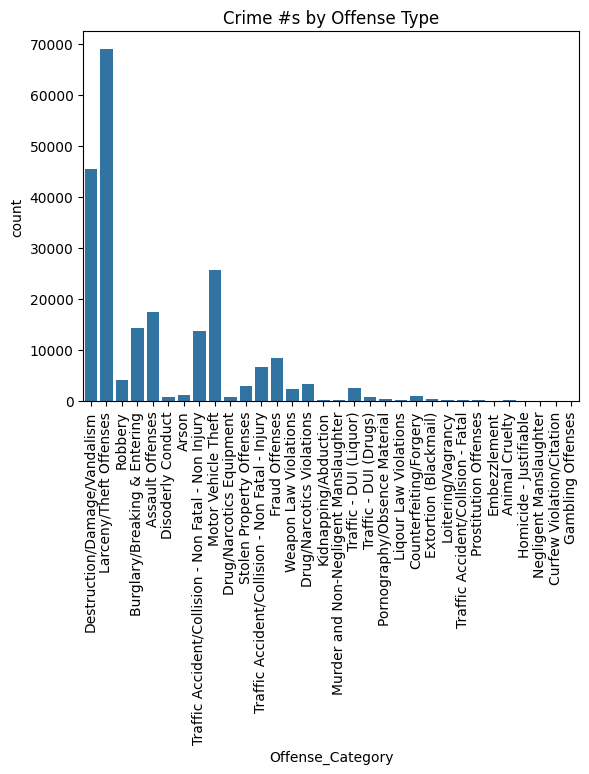

In [114]:
#visualizing the data by offense category
sns.countplot(crime_df, x = "Offense_Category")

#take current plot and add these adjustments
plt.title("Crime #s by Offense Type")
plt.xticks(rotation=90)

The above plot has too many categorical variables and is somewhat hard to read. I'm going to group categories below 1000 events into an other category and replot it. 

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
 [Text(0, 0, 'Destruction/Damage/Vandalism'),
  Text(1, 0, 'Larceny/Theft Offenses'),
  Text(2, 0, 'Robbery'),
  Text(3, 0, 'Burglary/Breaking & Entering'),
  Text(4, 0, 'Assault Offenses'),
  Text(5, 0, 'Other'),
  Text(6, 0, 'Traffic Accident/Collision - Non Fatal - Non Injury'),
  Text(7, 0, 'Motor Vehicle Theft'),
  Text(8, 0, 'Traffic Accident/Collision - Non Fatal - Injury'),
  Text(9, 0, 'Fraud Offenses'),
  Text(10, 0, 'Drug/Narcotics Violations')])

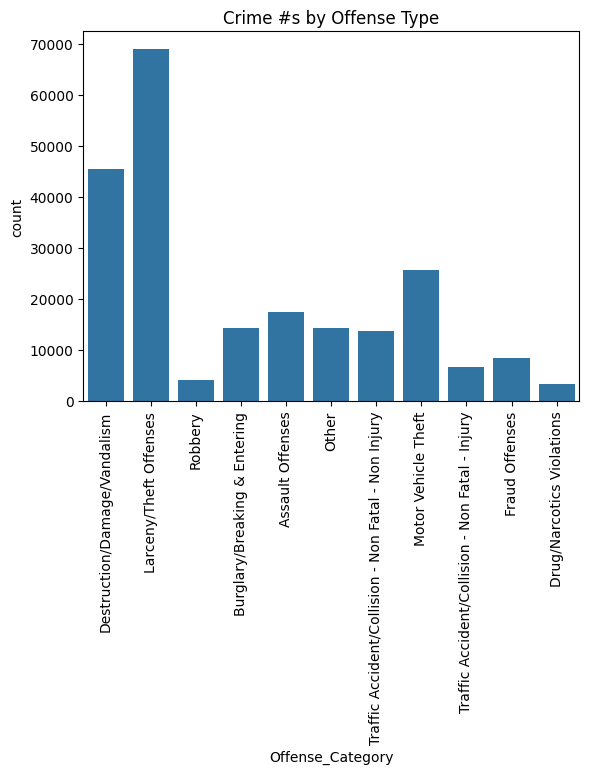

In [115]:
threshold = 3000
crime_df_other = crime_df

crime_df_by_off = crime_df_other['Offense_Category'].value_counts()                               #this creates a series. The offense_category are indices. 
other_offenses = pd.Series(crime_df_by_off[crime_df_by_off <= threshold].index)             #forcing this to be in a series


#isin will return boolean list of whether or not "offense category" is in the other offenses series. [True, False, True, True, etc.]
#boolean list is an acceptable input for loc which allows us to access the dataframe where those conditions are met and assign that column as "other"
crime_df_other.loc[crime_df_other['Offense_Category'].isin(other_offenses), "Offense_Category"] = "Other"   #isin will return boolean of whether or not "Offense Category" is in         

#visualizing the data by offense category
sns.countplot(crime_df_other, x = "Offense_Category")

#take current plot and add these adjustments
plt.title("Crime #s by Offense Type")
plt.xticks(rotation=90)





Just so we can keep analyzing the vehicle theft data, I'm going to break it down by neighborhood to see if there are any trends there. 

In [116]:
veh_by_nbr = crime_df_other[crime_df_other['Offense_Category'] == 'Motor Vehicle Theft']['NCD_name'].value_counts(normalize = True)
print(veh_by_nbr)
nbr_labels = pd.Series(veh_by_nbr.index)

NCD_name
South End       0.209087
South Tacoma    0.208183
New Tacoma      0.175846
Eastside        0.113336
Central         0.098741
West End        0.083910
North End       0.077577
North East      0.033320
Name: proportion, dtype: float64


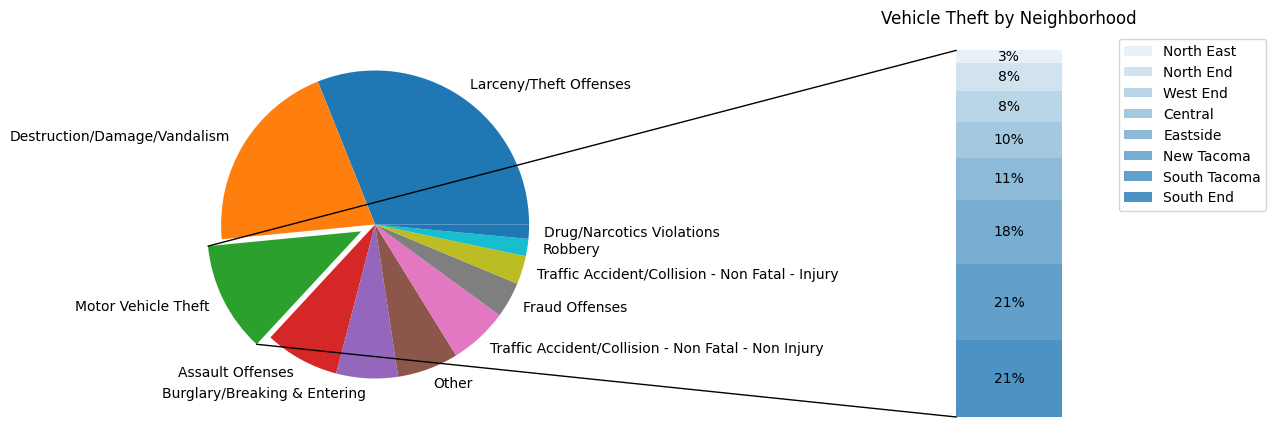

In [117]:
#using this https://matplotlib.org/stable/gallery/pie_and_polar_charts/bar_of_pie.html example
#make figure and assign axis objects
#1 row and 2 columns of subplots
#returns figure object and axes. ax1 for left; ax2 for right
fig, (ax1, ax2) = plt.subplots(1,2, figsize = (15,5))
target_label = 'Motor Vehicle Theft'
explode_val = 0.1

crime_values = crime_df_other['Offense_Category'].value_counts()
crime_list = list(crime_values.index)

explode = [explode_val if label == target_label else 0 for label in crime_list]
veh_index = explode.index(0.1) #find index to use with wedge later


wedges, *_ = ax1.pie(crime_values, labels = crime_values.index, explode= explode)

#bar chart parameters
bottom = 1
width = .2

# Adding from the top matches the legend.
for j, (height, label) in enumerate(reversed([*zip(veh_by_nbr, nbr_labels)])):
    bottom -= height
    bc = ax2.bar(0, height, width, bottom=bottom, color='C0', label=label,
                 alpha=0.1 + 0.1 * j)
    ax2.bar_label(bc, labels=[f"{height:.0%}"], label_type='center')


ax2.set_title('Vehicle Theft by Neighborhood')
ax2.legend()
ax2.axis('off')
ax2.set_xlim(- 2.5 * width, 2.5 * width)

# use ConnectionPatch to draw lines between the two plots
theta2, theta1 = wedges[veh_index].theta1, wedges[veh_index].theta2
center, r = wedges[veh_index].center, wedges[veh_index].r
bar_height = sum(veh_by_nbr)

# draw top connecting line
x = r * np.cos(np.pi / 180 * theta2) + center[0]
y = r * np.sin(np.pi / 180 * theta2) + center[1]
con = ConnectionPatch(xyA=(-width / 2, bar_height), coordsA=ax2.transData,
                      xyB=(x, y), coordsB=ax1.transData)
con.set_color([0, 0, 0])
con.set_linewidth(1)
ax2.add_artist(con)

# draw bottom connecting line
x = r * np.cos(np.pi / 180 * theta1) + center[0]
y = r * np.sin(np.pi / 180 * theta1) + center[1]
con = ConnectionPatch(xyA=(-width / 2, 0), coordsA=ax2.transData,
                      xyB=(x, y), coordsB=ax1.transData)
con.set_color([0, 0, 0])
ax2.add_artist(con)
con.set_linewidth(1)

plt.show()

Most of the vehicle thefts occur in South Tacoma. The further North and West you go, the less vehicle theft it seems like. 